In [37]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [38]:
# 1.Load the data

df = pd.read_csv('netflix_titles.csv')

In [39]:
# Initial exploration of the Netflix dataset

In [40]:
# 2. Display the first 5 rows to understand how the dataset looks

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [41]:
# 3. Get information about columns, data types, and missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [42]:
# 4. Generate statistical summary for numerical columns

df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [43]:
# 5. Check the number of rows and columns in the dataset

print("Rows and columns : " ,df.shape)

Rows and columns :  (8807, 12)


In [44]:
# 6. Display all column names present in the dataset

print("Column Names : ",df.columns)

Column Names :  Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [32]:
# 7. Check the total number of missing values in each column
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

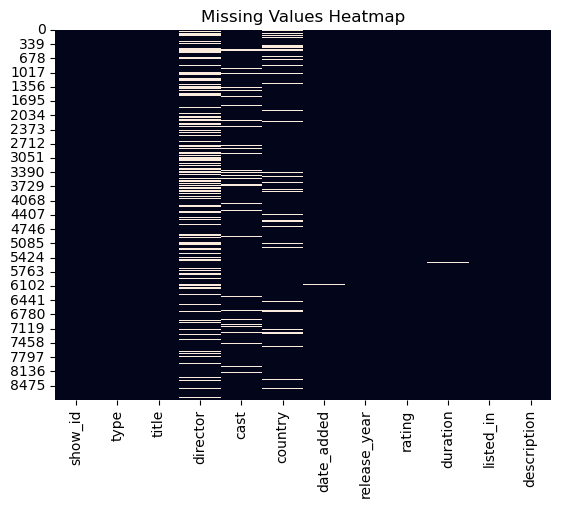

In [45]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [46]:
# 8. Fill missing values in the director column with 'Unknown'
# This helps retain rows instead of removing useful data
df['director'] = df['director'].fillna('Unknown')

In [47]:
# 9. Fill missing values in the country column with 'Not Available'
# This avoids null values during country-based analysis
df['country'] = df['country'].fillna('Not Available')

In [48]:
# 10. Remove rows where rating values are missing
# Ratings are important for content classification analysis
print("Rows before cleaning:", df.shape[0])

df.dropna(subset=['rating'], inplace=True)

print("Rows after cleaning:", df.shape[0])

Rows before cleaning: 8807
Rows after cleaning: 8803


In [49]:
# 11. Recheck missing values after data cleaning
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast            825
country           0
date_added       10
release_year      0
rating            0
duration          3
listed_in         0
description       0
dtype: int64

In [50]:
# 12. Check the updated shape of the dataset after handling missing values
df.shape

(8803, 12)

In [51]:
# 13. Count the number of duplicate rows in the dataset
df.duplicated().sum()

0

In [52]:
# 14. Remove duplicate rows from the dataset
rows_before = df.shape[0]

df.drop_duplicates(inplace=True)

rows_after = df.shape[0]

print("Duplicate rows removed:", rows_before - rows_after)

Duplicate rows removed: 0


In [53]:
# 15. Generate statistical summary after data cleaning
# Helps verify the dataset consistency after removing duplicates

df.describe()

,release_year
count,8803.000000
mean,2014.179825
std,8.821247
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [54]:
# 16. Display all column names for reference before further analysis
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [55]:
# 17. Analyze the distribution of Movies and TV Shows on Netflix
content_type = df['type'].value_counts()

print(content_type)

type
Movie      6129
TV Show    2674
Name: count, dtype: int64


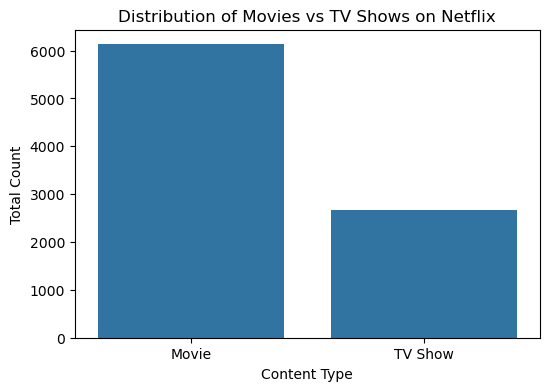

In [56]:
# 18. Visualize Movies vs TV Shows distribution

plt.figure(figsize=(6,4))

sns.countplot(x='type', data=df)

plt.title('Distribution of Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Total Count')

plt.show()

In [57]:
# 19. Calculate the average release year by content type
df.groupby('type')['release_year'].mean()

type
Movie      2013.120574
TV Show    2016.607704
Name: release_year, dtype: float64

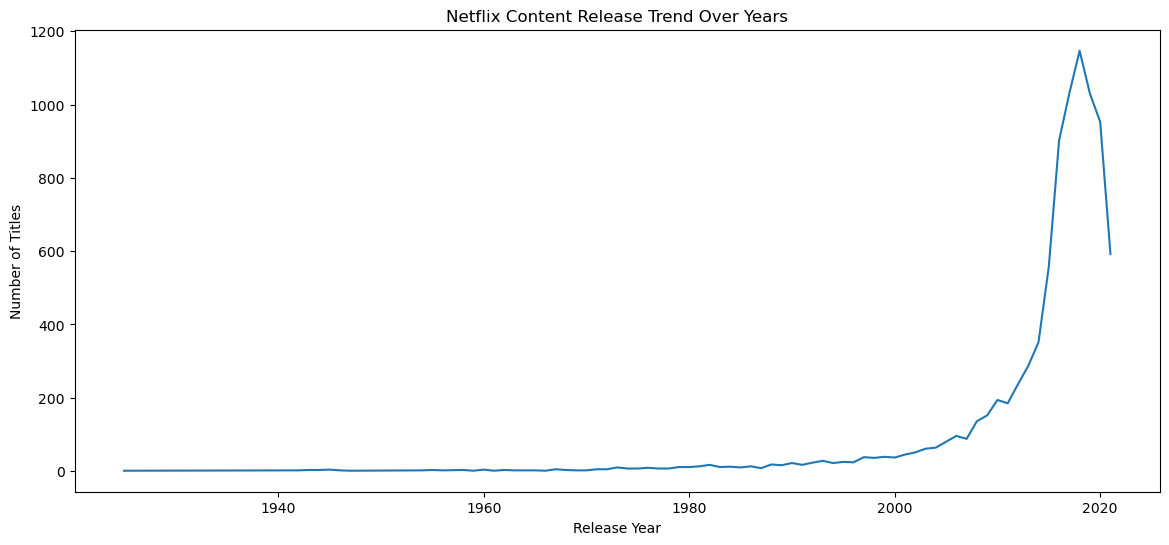

In [58]:
# 20. Analyze Netflix content release trend over the years

plt.figure(figsize=(14,6))

yearly_content = df['release_year'].value_counts().sort_index()

plt.plot(yearly_content.index, yearly_content.values)

plt.title('Netflix Content Release Trend Over Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

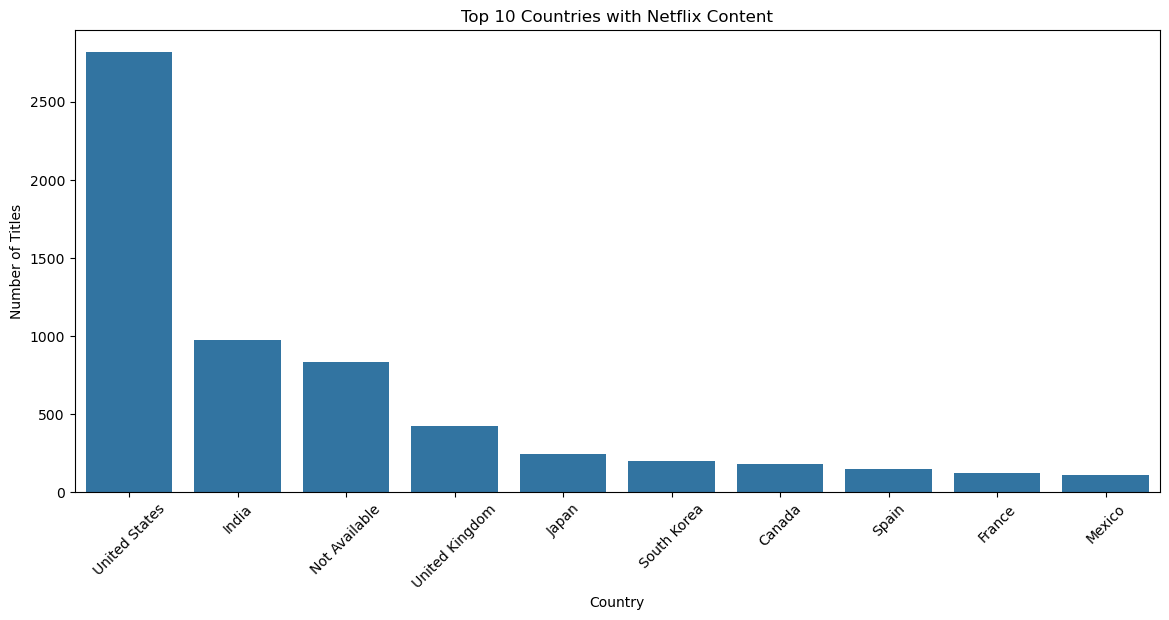

In [59]:
# 21. Identify top 10 countries producing Netflix content

top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.title('Top 10 Countries with Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.show()

In [63]:
# 22. Split and normalize country values for detailed analysis

df['country'] = df['country'].str.split(',')

df = df.explode('country')

df['country'] = df['country'].str.strip()

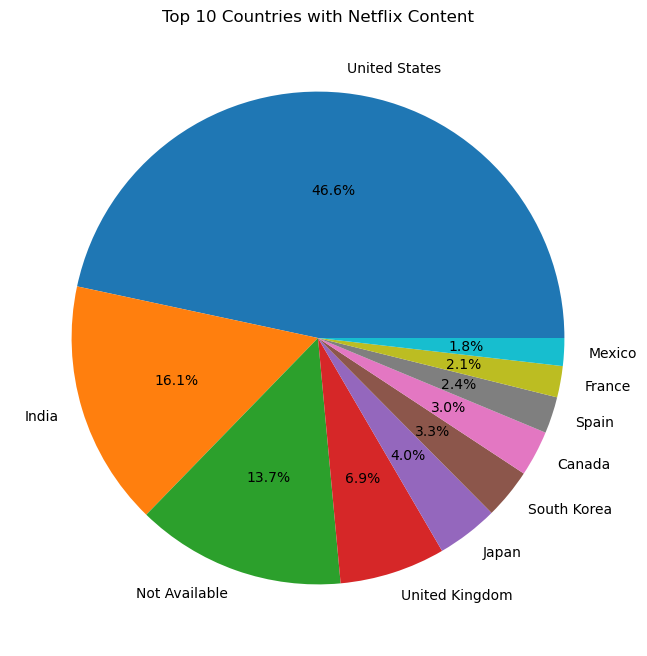

In [64]:
# 23. Visualize the contribution of top 10 countries using a pie chart

plt.figure(figsize=(8,8))

plt.pie(
    top_countries.values,
    labels=top_countries.index,
    autopct='%1.1f%%'
)

plt.title('Top 10 Countries with Netflix Content')

plt.show()

In [65]:
# 24. Count the number of Netflix titles released each year

year_data = df['release_year'].value_counts().sort_index()

year_data

release_year
1925       1
1942       2
1943       3
1944       4
1945       4
        ... 
2017    1275
2018    1392
2019    1208
2020    1055
2021     658
Name: count, Length: 74, dtype: int64

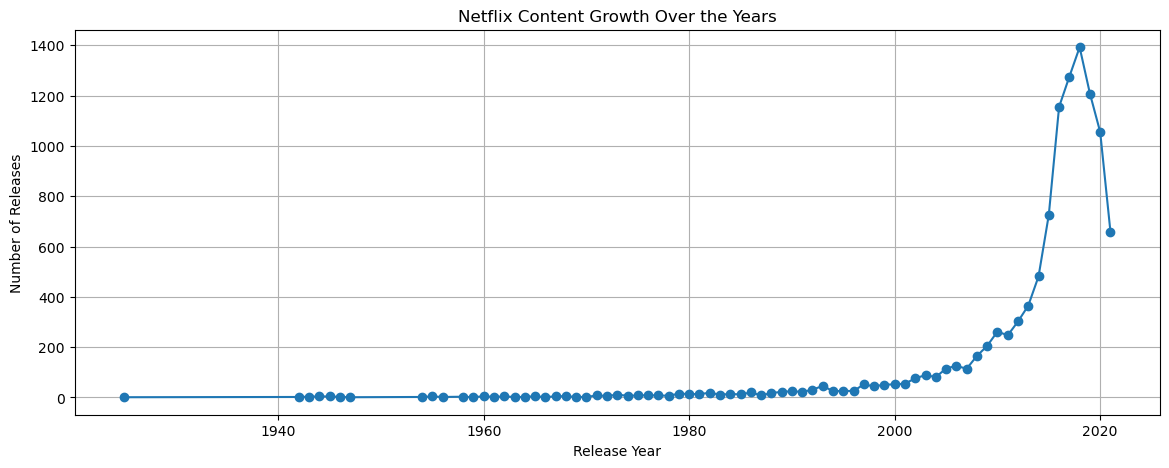

In [66]:
# 25. Visualize Netflix content growth over the years

plt.figure(figsize=(14,5))

plt.plot(
    year_data.index,
    year_data.values,
    marker='o'
)

plt.title('Netflix Content Growth Over the Years')

plt.xlabel('Release Year')

plt.ylabel('Number of Releases')

plt.grid(True)

plt.show()

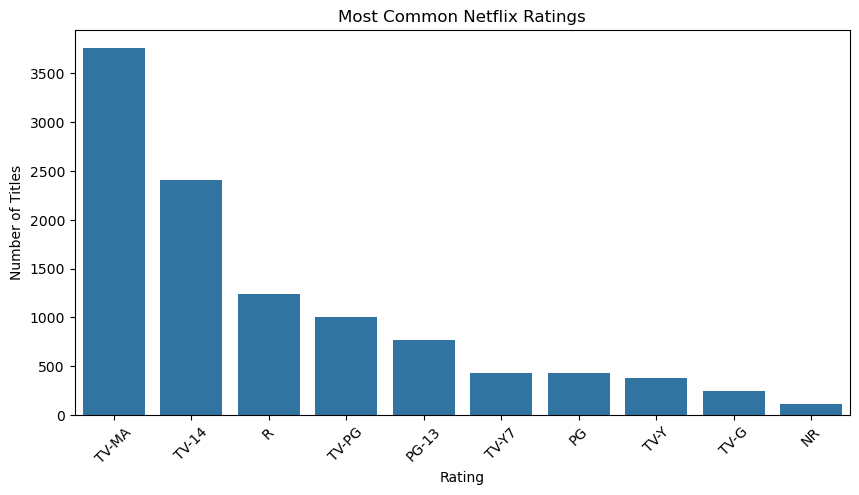

In [67]:
# 26. Identify the most common content ratings on Netflix

rating = df['rating'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=rating.index,
    y=rating.values
)

plt.title('Most Common Netflix Ratings')

plt.xlabel('Rating')

plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.show()

In [68]:
# 27. Display the 10 oldest Netflix titles

oldest_titles = df.sort_values(by='release_year')

oldest_titles[['title', 'release_year']].head(10)

,title,release_year
4250,Pioneers: First Women Filmmakers*,1925
8205,The Battle of Midway,1942
7790,Prelude to War,1942
8660,Undercover: How to Operate Behind Enemy Lines,1943
8739,Why We Fight: The Battle of Russia,1943
8763,WWII: Report from the Aleutians,1943
8419,The Memphis Belle: A Story of a\nFlying Fortress,1944
8640,Tunisian Victory,1944
8640,Tunisian Victory,1944
8436,The Negro Soldier,1944


In [69]:
# 28. Display the 10 latest Netflix titles

latest_titles = df.sort_values(
    by='release_year',
    ascending=False
)

latest_titles[['title', 'release_year']].head(10)

,title,release_year
15,Dear White People,2021
40,He-Man and the Masters of the Universe,2021
39,Chhota Bheem,2021
10,"Vendetta: Truth, Lies and The Mafia",2021
9,The Starling,2021
14,Crime Stories: India Detectives,2021
1,Blood & Water,2021
2,Ganglands,2021
3,Jailbirds New Orleans,2021
31,Chicago Party Aunt,2021


In [70]:
# 29. Identify the top 10 genres available on Netflix

top_genres = df['listed_in'].value_counts().head(10)

top_genres

listed_in
Dramas, International Movies                        487
Documentaries                                       424
Dramas, Independent Movies, International Movies    393
Stand-Up Comedy                                     335
Comedies, Dramas, International Movies              314
Documentaries, International Movies                 309
Kids' TV                                            304
Children & Family Movies, Comedies                  291
Children & Family Movies                            257
Action & Adventure                                  197
Name: count, dtype: int64

In [72]:
# 30. Split and normalize genres for accurate genre-wise analysis

df['listed_in'] = df['listed_in'].str.split(',')

df = df.explode('listed_in')

df['listed_in'] = df['listed_in'].str.strip()

In [73]:
# 31. Recalculate the top 10 genres after normalization

top_genres = df['listed_in'].value_counts().head(10)

top_genres

listed_in
International Movies        3513
Dramas                      3201
Comedies                    1981
International TV Shows      1464
Action & Adventure          1182
Documentaries               1118
Independent Movies          1040
TV Dramas                    852
Children & Family Movies     845
Thrillers                    806
Name: count, dtype: int64

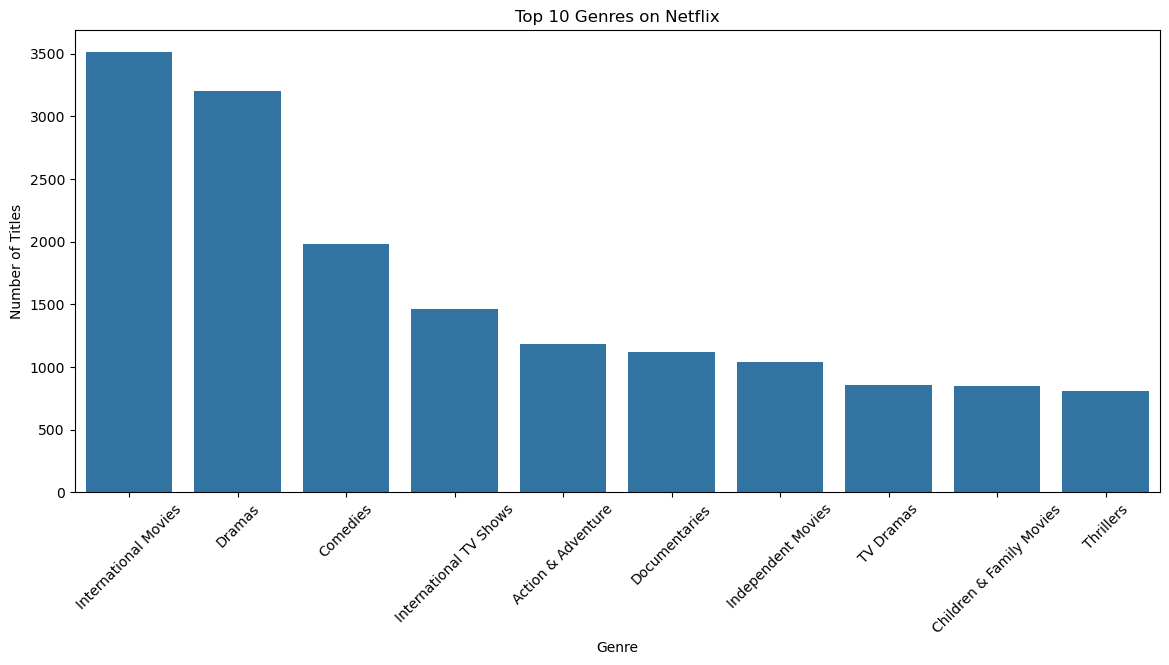

In [74]:
# 32. Visualize the top 10 genres on Netflix

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_genres.index,
    y=top_genres.values
)

plt.title('Top 10 Genres on Netflix')

plt.xlabel('Genre')

plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.show()

In [75]:
# 33. Filter only Movies from the dataset

movies = df[df['type'] == 'Movie']

movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Not Available,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",United States,"September 24, 2021",1993,TV-MA,125 min,Dramas,"On a photo shoot in Ghana, an American model s..."
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",United States,"September 24, 2021",1993,TV-MA,125 min,Independent Movies,"On a photo shoot in Ghana, an American model s..."
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",United States,"September 24, 2021",1993,TV-MA,125 min,International Movies,"On a photo shoot in Ghana, an American model s..."


In [76]:
# 34. Filter only TV Shows from the dataset

tv_shows = df[df['type'] == 'TV Show']

tv_shows.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Available,"September 24, 2021",2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Available,"September 24, 2021",2021,TV-MA,1 Season,International TV Shows,To protect his family from a powerful drug lor...


In [77]:
# 35. Display Netflix titles released after 2020

recent_titles = df[df['release_year'] > 2020]

recent_titles[['title', 'release_year']].head()

,title,release_year
1,Blood & Water,2021
1,Blood & Water,2021
1,Blood & Water,2021
2,Ganglands,2021
2,Ganglands,2021


In [78]:
# 36. Filter Indian movies available on Netflix

indian_movies = df[
    (df['country'] == 'India') &
    (df['type'] == 'Movie')
]

indian_movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,Comedies,When the father of the man she loves insists t...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,International Movies,When the father of the man she loves insists t...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,Romantic Movies,When the father of the man she loves insists t...
29,s30,Movie,Paranoia,Robert Luketic,"Liam Hemsworth, Gary Oldman, Amber Heard, Harr...",India,"September 19, 2021",2013,PG-13,106 min,Thrillers,"Blackmailed by his company's CEO, a low-level ..."
105,s106,Movie,Angamaly Diaries,Lijo Jose Pellissery,"Antony Varghese, Reshma Rajan, Binny Rinky Ben...",India,"September 5, 2021",2017,TV-14,128 min,Action & Adventure,After growing up amidst the gang wars of his h...


In [79]:
# 37. Calculate the average release year by content type

group_data_avg = df.groupby('type')['release_year'].mean()

group_data_avg

type
Movie      2012.743084
TV Show    2016.709030
Name: release_year, dtype: float64